# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations

**Post-hoc Analysis: MDS Visualization and Noise-Whitened RDMs | Michael Zhou | Georgia Tech ECE**

This notebook computes two post-hoc analyses motivated by Kriegeskorte & Wei (2021)
on the saved population matrices from Experiments 1 and 2. Neither analysis requires
rerunning the Flyvis simulations — all computations operate on saved `.npz` results
files and run on CPU.

**MDS visualization** embeds the mean CC and random cosine RDMs into 2D, making the
circular direction geometry and polarity block structure directly visible without
requiring interpretation of the full distance matrix.

**Noise-whitened RDMs** compute Mahalanobis-distance RDMs using a noise covariance
estimated from model-level variability across the 50 CC models, following Kriegeskorte
& Wei (2021). Whitened RDM correlations provide a robustness check on the primary
cosine RDM result by accounting for noise covariance structure. Within-polarity
circular structure is also tested on the whitened RDM as a secondary robustness check.

**Key question:** Does the representational geometry fidelity signal — and the
within-polarity circular direction structure — hold after noise covariance is accounted
for, and is the circular geometry visible as a ring structure in a low-dimensional MDS
embedding?

**Prerequisites:** `results_exp1_50models_full_shiu.npz` and
`results_exp2_50models_full_shiu.npz` must be present in `results/` from Experiments
1 and 2. CPU runtime sufficient — no GPU needed.

**References**
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Maisak et al. 2013. A directional tuning map of Drosophila elementary motion detectors. *Nature* 500, 212–216. https://www.nature.com/articles/nature12320

## Analysis Design

**Population matrices loaded from:**
- `results/results_exp1_50models_full_shiu.npz` — Exp 1, ON edges (n=50, 12 conditions × 65 cell types)
- `results/results_exp2_50models_full_shiu.npz` — Exp 2, ON+OFF edges (n=50, 24 conditions × 65 cell types)

**Networks:** Same 50 connectome-constrained (CC) and 50 stability-constrained random
models as Experiments 1 and 2 (full Shiu-style shuffle, MAX_ATTEMPTS=100, seed=42).
See those notebooks for full network and baseline descriptions.

**Reproducibility:** seed=42 (`numpy`); `np.random.seed(SEED)` used globally.

**Metrics:**
- MDS embedding — projects mean CC and random cosine RDMs into 2D (sklearn
 `MDS`, precomputed dissimilarity, `normalized_stress=False`, seed=42); visualizes
 circular direction geometry and polarity block structure
- Noise-whitened RDM — Mahalanobis distance using noise covariance estimated from
 model-level residuals (50 models × n_stim observations, 65-dim); ridge
 regularization applied for numerical stability (1e-4 × mean eigenvalue)
- Whitened RDM correlation — Spearman r and Kendall τ between whitened CC and
 random RDMs; stimulus-label permutation test (Nili et al. 2014, 10,000
 permutations)
- Within-polarity circular structure (whitened) — Spearman r of whitened ON-ON
 and OFF-OFF submatrices vs circular distance reference; permutation test
 (10,000 permutations); robustness check against cosine RDM within-polarity result

**Interpretation:** Whitened RDM results are a robustness check only — the cosine RDM
remains the primary metric. Ill-conditioned covariance estimates (condition numbers
~1e7) are expected given the limited sample size (50 models, 65 dimensions); results
should be interpreted directionally rather than as precise effect size estimates.

**RSA reference values (Experiments 1 & 2, n=50 canonical):**
- Exp 1 (ON edges): Spearman r = 0.686, p < 0.0001
- Exp 2 (ON+OFF edges): Spearman r = 0.846, p < 0.0001

Loading Experiment 1 results (ON edges, n=50)...
  cc_pop_matrices:   (50, 12, 65)
  rand_pop_matrices: (50, 12, 65)

Loading Experiment 2 results (ON+OFF edges, n=50)...
  cc_pop_matrices:   (50, 24, 65)
  rand_pop_matrices: (50, 24, 65)

MDS VISUALIZATION
Saved: figures/mds_exp1_on_edges_50models.png


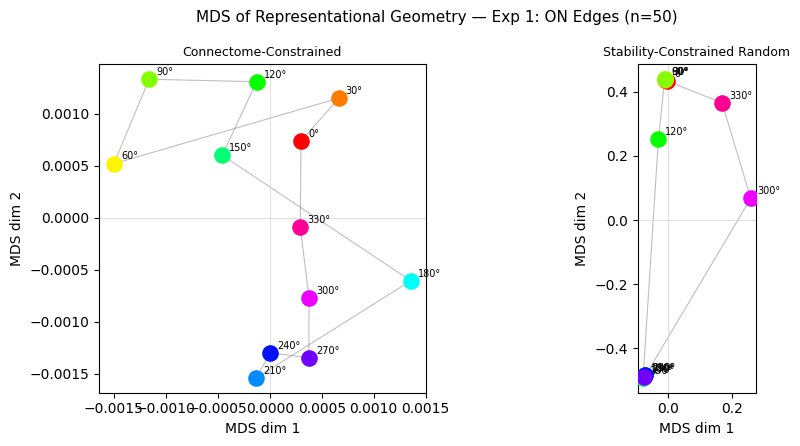

Saved: figures/mds_exp2_on_off_edges_50models.png


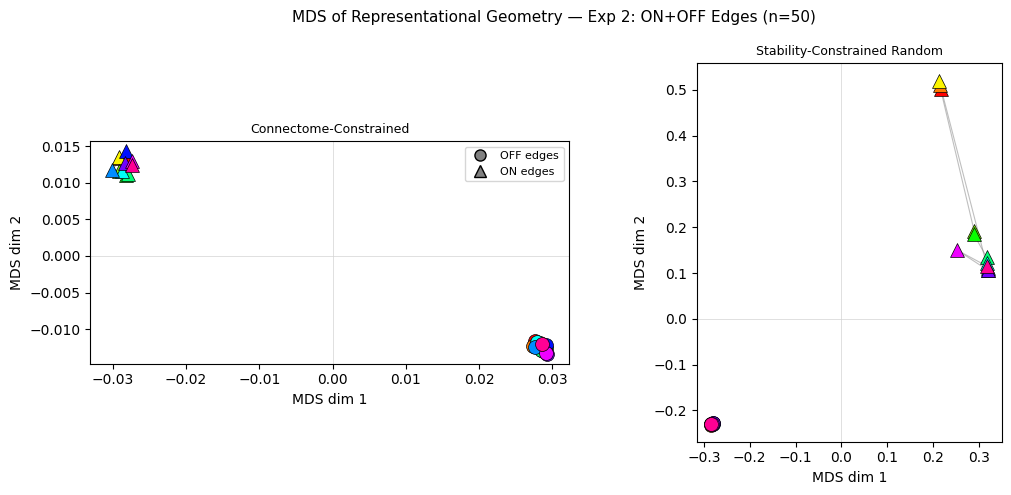


NOISE-WHITENED RDMs

Note: noise covariance estimated from model-level variability across
50 CC models (residuals from mean population matrix). This is a proxy
for response variability — not single-trial neural noise. Interpret
whitened RDM results as a robustness check, not a replacement for
the cosine RDM primary result.

--- Experiment 1: ON edges ---
  Noise covariance shape: (65, 65)
  Condition number: 4.97e+07

  Whitened RDM correlation (CC vs Random):
  Spearman r = 0.344, p = 0.0046 | Kendall τ = 0.269, p = 0.0014  [analytical]
  Spearman r = 0.344, p_perm = 0.0129 | Kendall τ = 0.269, p_perm = 0.0066  [permutation]

  Reference — cosine RDM (primary result):
  Spearman r = 0.686, p < 0.0001 | Kendall τ = 0.515, p < 0.0001

--- Experiment 2: ON+OFF edges ---
  Noise covariance shape: (65, 65)
  Condition number: 4.28e+07

  Whitened RDM correlation (CC vs Random):
  Spearman r = 0.728, p = 0.0000 | Kendall τ = 0.540, p = 0.0000  [analytical]
  Spearman r = 0.728, p_perm = 0.

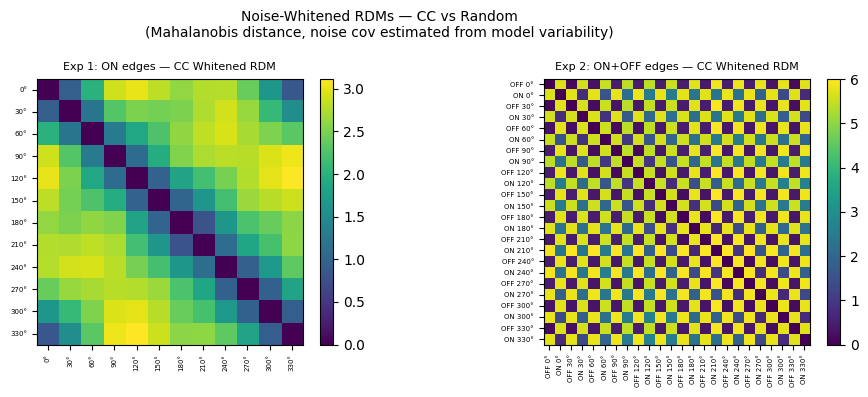


--- WITHIN-POLARITY WHITENED RDM FIGURE (Exp 2) ---
Saved: figures/within_polarity_blocks_whitened_exp2_50models.png


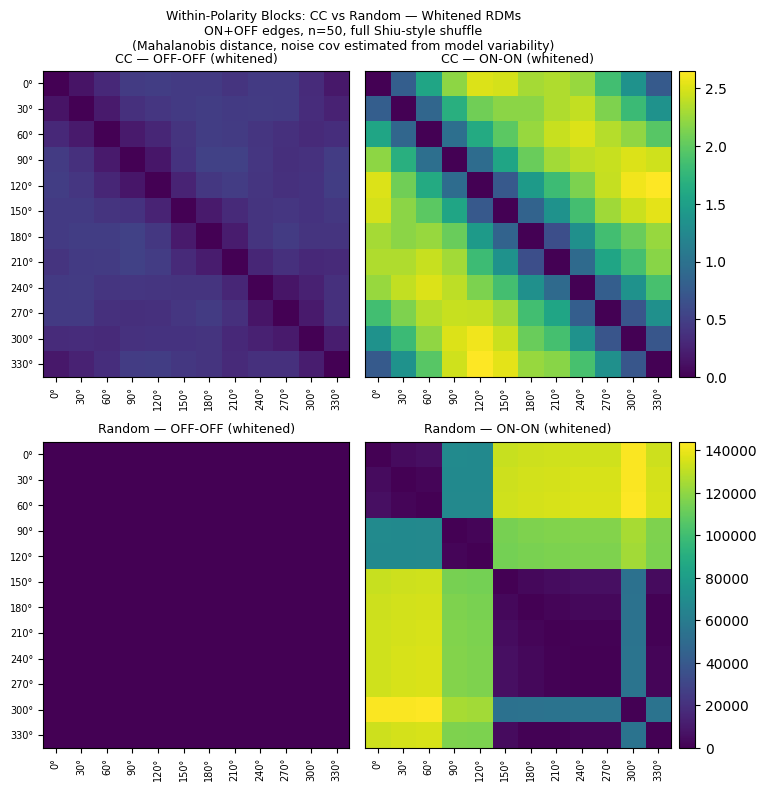


WITHIN-POLARITY CIRCULAR STRUCTURE — WHITENED RDMs (Exp 2)

Note: within-polarity structure tested on whitened mean CC RDM.
Robustness check against the cosine RDM within-polarity result.

  ON-ON  block (whitened):
    Spearman r = 0.952, p = 0.0000  [analytical]
    p_perm = 0.0000  [10000 permutations]
    0/10000 permutations exceeded observed r

  OFF-OFF block (whitened):
    Spearman r = 0.658, p = 0.0000  [analytical]
    p_perm = 0.0000  [10000 permutations]
    0/10000 permutations exceeded observed r

  Whitened Δr = 0.294 (ON-ON r = 0.952, OFF-OFF r = 0.658)

  Reference — cosine RDM (primary result):
  ON-ON r = 0.937, p_perm < 0.0001
  OFF-OFF r = 0.799, p_perm < 0.0001
  Δr = 0.138

SUMMARY
  MDS figures saved:
    figures/mds_exp1_on_edges_50models.png
    figures/mds_exp2_on_off_edges_50models.png

  Whitened RDM results:
    Exp 1: Spearman r = 0.344, p_perm = 0.0129 | τ = 0.269, p_perm = 0.0066
    Exp 2: Spearman r = 0.728, p_perm = 0.0000 | τ = 0.540, p_perm = 0.0

In [2]:
"""
Post-hoc Analysis: MDS Visualization and Noise-Whitened RDMs
for Connectome-Constrained Neural Emulations

Loads saved population matrices from Experiments 1 and 2 and computes:
1. MDS embedding of mean CC cosine RDM (visualizes circular direction geometry)
2. Noise-whitened RDMs using population covariance across models as noise estimate
3. RSA on whitened RDMs as a robustness check against the cosine RDM result

Operates entirely on saved .npz results — no Flyvis or GPU required.
Run on CPU runtime.

References:
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry.
  Nature Reviews Neuroscience 22, 703–718.
- Nili et al. 2014. PLOS Computational Biology 10(4): e1003553.
- Maisak et al. 2013. Nature 500, 212–216.
"""

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, kendalltau
from sklearn.manifold import MDS
import torch

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.use_deterministic_algorithms(True)

# ── 1. LOAD RESULTS ───────────────────────────────────────────────────────────

results_dir = Path("results")

print("Loading Experiment 1 results (ON edges, n=50)...")
exp1 = np.load(
    results_dir / "results_exp1_50models_full_shiu.npz",
    allow_pickle=True
)
cc1   = exp1["cc_pop_matrices"]    # (50, 12, 65)
rand1 = exp1["rand_pop_matrices"]  # (50, 12, 65)
print(f"  cc_pop_matrices:   {cc1.shape}")
print(f"  rand_pop_matrices: {rand1.shape}")

print("\nLoading Experiment 2 results (ON+OFF edges, n=50)...")
exp2 = np.load(
    results_dir / "results_exp2_50models_full_shiu.npz",
    allow_pickle=True
)
cc2   = exp2["cc_pop_matrices"]    # (50, 24, 65)
rand2 = exp2["rand_pop_matrices"]  # (50, 24, 65)
print(f"  cc_pop_matrices:   {cc2.shape}")
print(f"  rand_pop_matrices: {rand2.shape}")

# ── 2. HELPERS ────────────────────────────────────────────────────────────────

def build_cosine_rdm(pop_matrix):
    """Cosine distance RDM from (n_stim, n_units) population matrix."""
    pop_matrix = pop_matrix + 1e-10  # guard against zero-norm rows
    norms = np.linalg.norm(pop_matrix, axis=1, keepdims=True)
    normed = pop_matrix / norms
    sim = normed @ normed.T
    sim = np.clip(sim, -1.0, 1.0)
    return 1.0 - sim  # cosine distance


def build_whitened_rdm(pop_matrix, noise_cov):
    """
    Mahalanobis-distance RDM using estimated noise covariance.

    Noise covariance is estimated from model-to-model variability in
    population vectors, serving as a proxy for noise in the response
    space (Kriegeskorte & Wei 2021).

    Args:
        pop_matrix: (n_stim, n_units) — mean population matrix across models
        noise_cov:  (n_units, n_units) — estimated noise covariance

    Returns:
        rdm: (n_stim, n_stim) Mahalanobis distance RDM
    """
    # Regularize covariance for numerical stability (ridge regularization)
    ridge = 1e-4 * np.trace(noise_cov) / noise_cov.shape[0]
    cov_reg = noise_cov + ridge * np.eye(noise_cov.shape[0])

    try:
        cov_inv = np.linalg.inv(cov_reg)
    except np.linalg.LinAlgError:
        print("    WARNING: covariance matrix singular — using pseudoinverse")
        cov_inv = np.linalg.pinv(cov_reg)

    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                diff = pop_matrix[i] - pop_matrix[j]
                rdm[i, j] = np.sqrt(np.maximum(diff @ cov_inv @ diff, 0))
    return rdm


def estimate_noise_cov(pop_matrices):
    """
    Estimate noise covariance from model-level variability.

    Treats each model's population matrix as one sample, computes
    the covariance of residuals from the mean across models.

    Args:
        pop_matrices: (n_models, n_stim, n_units)

    Returns:
        noise_cov: (n_units, n_units)
    """
    mean_pop = pop_matrices.mean(axis=0)                  # (n_stim, n_units)
    residuals = pop_matrices - mean_pop[np.newaxis, :, :] # (n_models, n_stim, n_units)
    # Flatten stimuli and models to get (n_models * n_stim, n_units)
    flat = residuals.reshape(-1, pop_matrices.shape[2])
    noise_cov = np.cov(flat.T)                            # (n_units, n_units)
    return noise_cov


def rdm_similarity(rdm1, rdm2):
    """Spearman r and Kendall tau on upper triangle."""
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


def permutation_test_rdm(rdm1, rdm2, n_permutations=10000, seed=42):
    """Stimulus-label permutation test (Nili et al. 2014)."""
    rng = np.random.default_rng(seed)
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    obs_r,   _ = spearmanr(rdm1[idx], rdm2[idx])
    obs_tau, _ = kendalltau(rdm1[idx], rdm2[idx])
    null_r   = np.zeros(n_permutations)
    null_tau = np.zeros(n_permutations)
    for i in range(n_permutations):
        perm = rng.permutation(n)
        rdm2_perm = rdm2[np.ix_(perm, perm)]
        null_r[i],   _ = spearmanr(rdm1[idx], rdm2_perm[idx])
        null_tau[i], _ = kendalltau(rdm1[idx], rdm2_perm[idx])
    p_r   = np.mean(null_r   >= obs_r)
    p_tau = np.mean(null_tau >= obs_tau)
    return obs_r, p_r, obs_tau, p_tau, null_r, null_tau


# ── 3. MDS VISUALIZATION ─────────────────────────────────────────────────────

print("\n" + "="*60)
print("MDS VISUALIZATION")
print("="*60)

ANGLES = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]

# ── Experiment 1: ON edges ────────────────────────────────────────────────────

cc1_mean = cc1.mean(axis=0)     # (12, 65)
rand1_mean = rand1.mean(axis=0) # (12, 65)

cc1_rdm   = build_cosine_rdm(cc1_mean)
rand1_rdm = build_cosine_rdm(rand1_mean)

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED,
          normalized_stress=False)
cc1_mds   = mds.fit_transform(cc1_rdm)
rand1_mds = mds.fit_transform(rand1_rdm)

fig1, axes1 = plt.subplots(1, 2, figsize=(10, 4.5))
fig1.suptitle("MDS of Representational Geometry — Exp 1: ON Edges (n=50)",
              fontsize=11)

cmap = plt.cm.hsv
colors = [cmap(a / 360) for a in ANGLES]

for ax, coords, title in zip(
    axes1,
    [cc1_mds, rand1_mds],
    ["Connectome-Constrained", "Stability-Constrained Random"]
):
    for k, (x, y) in enumerate(coords):
        ax.scatter(x, y, color=colors[k], s=120, zorder=3)
        ax.annotate(f"{ANGLES[k]}°", (x, y),
                    textcoords="offset points", xytext=(5, 3), fontsize=7)
    # Draw lines connecting adjacent directions to show circular structure
    for k in range(len(ANGLES)):
        x0, y0 = coords[k]
        x1, y1 = coords[(k + 1) % len(ANGLES)]
        ax.plot([x0, x1], [y0, y1], "gray", linewidth=0.8, alpha=0.5, zorder=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("MDS dim 1")
    ax.set_ylabel("MDS dim 2")
    ax.axhline(0, color="lightgray", linewidth=0.5)
    ax.axvline(0, color="lightgray", linewidth=0.5)
    ax.set_aspect("equal")

plt.tight_layout()
fname_mds1 = "figures/mds_exp1_on_edges_50models.png"
fig1.savefig(fname_mds1, dpi=150, bbox_inches="tight")
print(f"Saved: {fname_mds1}")
plt.show()

# ── Experiment 2: ON+OFF edges ────────────────────────────────────────────────

cc2_mean   = cc2.mean(axis=0)   # (24, 65)
rand2_mean = rand2.mean(axis=0) # (24, 65)

cc2_rdm   = build_cosine_rdm(cc2_mean)
rand2_rdm = build_cosine_rdm(rand2_mean)

cc2_mds   = mds.fit_transform(cc2_rdm)
rand2_mds = mds.fit_transform(rand2_rdm)

# Labels: interleaved OFF 0°, ON 0°, OFF 30°, ON 30°, ...
stim_labels_2 = []
for a in ANGLES:
    stim_labels_2.append(f"OFF {a}°")
    stim_labels_2.append(f"ON {a}°")

# Color by direction (same hue for ON and OFF of same direction)
# Marker shape distinguishes polarity
off_indices = list(range(0, 24, 2))
on_indices  = list(range(1, 24, 2))

fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5))
fig2.suptitle("MDS of Representational Geometry — Exp 2: ON+OFF Edges (n=50)",
              fontsize=11)

for ax, coords, title in zip(
    axes2,
    [cc2_mds, rand2_mds],
    ["Connectome-Constrained", "Stability-Constrained Random"]
):
    for k in off_indices:
        angle = ANGLES[k // 2]
        ax.scatter(coords[k, 0], coords[k, 1],
                   color=cmap(angle / 360), s=100, marker="o",
                   edgecolors="black", linewidths=0.5, zorder=3,
                   label=f"OFF {angle}°" if k == 0 else "")
    for k in on_indices:
        angle = ANGLES[k // 2]
        ax.scatter(coords[k, 0], coords[k, 1],
                   color=cmap(angle / 360), s=100, marker="^",
                   edgecolors="black", linewidths=0.5, zorder=3,
                   label=f"ON {angle}°" if k == 1 else "")
    # Connect adjacent same-polarity directions
    for indices in [off_indices, on_indices]:
        for i in range(len(indices)):
            x0, y0 = coords[indices[i]]
            x1, y1 = coords[indices[(i + 1) % len(indices)]]
            ax.plot([x0, x1], [y0, y1], "gray", linewidth=0.8,
                    alpha=0.5, zorder=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("MDS dim 1")
    ax.set_ylabel("MDS dim 2")
    ax.axhline(0, color="lightgray", linewidth=0.5)
    ax.axvline(0, color="lightgray", linewidth=0.5)
    ax.set_aspect("equal")

# Single legend: circle = OFF, triangle = ON
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray",
           markersize=8, markeredgecolor="black", label="OFF edges"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="gray",
           markersize=8, markeredgecolor="black", label="ON edges"),
]
axes2[0].legend(handles=legend_elements, fontsize=8, loc="best")

plt.tight_layout()
fname_mds2 = "figures/mds_exp2_on_off_edges_50models.png"
fig2.savefig(fname_mds2, dpi=150, bbox_inches="tight")
print(f"Saved: {fname_mds2}")
plt.show()


# ── 4. NOISE-WHITENED RDMs ────────────────────────────────────────────────────

print("\n" + "="*60)
print("NOISE-WHITENED RDMs")
print("="*60)

print("\nNote: noise covariance estimated from model-level variability across")
print("50 CC models (residuals from mean population matrix). This is a proxy")
print("for response variability — not single-trial neural noise. Interpret")
print("whitened RDM results as a robustness check, not a replacement for")
print("the cosine RDM primary result.")

# ── Experiment 1 ──────────────────────────────────────────────────────────────

print("\n--- Experiment 1: ON edges ---")
noise_cov1 = estimate_noise_cov(cc1)    # (65, 65)
print(f"  Noise covariance shape: {noise_cov1.shape}")
print(f"  Condition number: {np.linalg.cond(noise_cov1):.2e}")

cc1_whitened_rdm   = build_whitened_rdm(cc1_mean,   noise_cov1)
rand1_whitened_rdm = build_whitened_rdm(rand1_mean,  noise_cov1)

r1_w, p1_w, tau1_w, ptau1_w = rdm_similarity(cc1_whitened_rdm, rand1_whitened_rdm)
print(f"\n  Whitened RDM correlation (CC vs Random):")
print(f"  Spearman r = {r1_w:.3f}, p = {p1_w:.4f} | "
      f"Kendall τ = {tau1_w:.3f}, p = {ptau1_w:.4f}  [analytical]")

obs_r1_w, p_r1_w, obs_tau1_w, p_tau1_w, null_r1_w, null_tau1_w = \
    permutation_test_rdm(cc1_whitened_rdm, rand1_whitened_rdm,
                          n_permutations=10000, seed=SEED)
print(f"  Spearman r = {obs_r1_w:.3f}, p_perm = {p_r1_w:.4f} | "
      f"Kendall τ = {obs_tau1_w:.3f}, p_perm = {p_tau1_w:.4f}  [permutation]")

print(f"\n  Reference — cosine RDM (primary result):")
print(f"  Spearman r = 0.686, p < 0.0001 | Kendall τ = 0.515, p < 0.0001")

# ── Experiment 2 ──────────────────────────────────────────────────────────────

print("\n--- Experiment 2: ON+OFF edges ---")
noise_cov2 = estimate_noise_cov(cc2)    # (65, 65)
print(f"  Noise covariance shape: {noise_cov2.shape}")
print(f"  Condition number: {np.linalg.cond(noise_cov2):.2e}")

cc2_whitened_rdm   = build_whitened_rdm(cc2_mean,   noise_cov2)
rand2_whitened_rdm = build_whitened_rdm(rand2_mean,  noise_cov2)

r2_w, p2_w, tau2_w, ptau2_w = rdm_similarity(cc2_whitened_rdm, rand2_whitened_rdm)
print(f"\n  Whitened RDM correlation (CC vs Random):")
print(f"  Spearman r = {r2_w:.3f}, p = {p2_w:.4f} | "
      f"Kendall τ = {tau2_w:.3f}, p = {ptau2_w:.4f}  [analytical]")

obs_r2_w, p_r2_w, obs_tau2_w, p_tau2_w, null_r2_w, null_tau2_w = \
    permutation_test_rdm(cc2_whitened_rdm, rand2_whitened_rdm,
                          n_permutations=10000, seed=SEED)
print(f"  Spearman r = {obs_r2_w:.3f}, p_perm = {p_r2_w:.4f} | "
      f"Kendall τ = {obs_tau2_w:.3f}, p_perm = {p_tau2_w:.4f}  [permutation]")

print(f"\n  Reference — cosine RDM (primary result):")
print(f"  Spearman r = 0.846, p < 0.0001 | Kendall τ = 0.651, p < 0.0001")

# ── 5. WHITENED RDM FIGURE ────────────────────────────────────────────────────

angle_labels = [f"{a}°" for a in ANGLES]

fig3, axes3 = plt.subplots(1, 2, figsize=(10, 4))
fig3.suptitle(
    "Noise-Whitened RDMs — CC vs Random\n"
    "(Mahalanobis distance, noise cov estimated from model variability)",
    fontsize=10
)

for ax, rdm_cc, rdm_rand, labels, title in zip(
    axes3,
    [cc1_whitened_rdm, cc2_whitened_rdm],
    [rand1_whitened_rdm, rand2_whitened_rdm],
    [angle_labels, stim_labels_2],
    ["Exp 1: ON edges", "Exp 2: ON+OFF edges"]
):
    # Show CC whitened RDM
    n = rdm_cc.shape[0]
    im = ax.imshow(rdm_cc, cmap="viridis", vmin=0)
    ax.set_title(f"{title} — CC Whitened RDM", fontsize=8)
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=5, rotation=90)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=5)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
fname_whitened = "figures/whitened_rdms_exp1_exp2_50models.png"
fig3.savefig(fname_whitened, dpi=150, bbox_inches="tight")
print(f"\nSaved: {fname_whitened}")
plt.show()


# ── 5a. WITHIN-POLARITY WHITENED RDM FIGURE ──────────────────────────────────

print("\n--- WITHIN-POLARITY WHITENED RDM FIGURE (Exp 2) ---")

off_idx = list(range(0, 24, 2))
on_idx  = list(range(1, 24, 2))

# Extract within-polarity submatrices from whitened CC and Random RDMs
cc2_w_off_off   = cc2_whitened_rdm[np.ix_(off_idx, off_idx)]
cc2_w_on_on     = cc2_whitened_rdm[np.ix_(on_idx,  on_idx)]
rand2_w_off_off = rand2_whitened_rdm[np.ix_(off_idx, off_idx)]
rand2_w_on_on   = rand2_whitened_rdm[np.ix_(on_idx,  on_idx)]

# Row-level shared colormaps — CC row and Random row scaled independently
vmax_cc_w   = max(cc2_w_off_off.max(),   cc2_w_on_on.max())
vmax_rand_w = max(rand2_w_off_off.max(), rand2_w_on_on.max())

fig4, axes4 = plt.subplots(2, 2, figsize=(8, 8.5))
fig4.subplots_adjust(right=0.91, wspace=0.05, top=0.91)
fig4.suptitle(
    "Within-Polarity Blocks: CC vs Random — Whitened RDMs\n"
    "ON+OFF edges, n=50, full Shiu-style shuffle\n"
    "(Mahalanobis distance, noise cov estimated from model variability)",
    fontsize=9
)

panels4 = [
    (axes4[0, 0], cc2_w_off_off,   "CC — OFF-OFF (whitened)",     vmax_cc_w),
    (axes4[0, 1], cc2_w_on_on,     "CC — ON-ON (whitened)",       vmax_cc_w),
    (axes4[1, 0], rand2_w_off_off, "Random — OFF-OFF (whitened)", vmax_rand_w),
    (axes4[1, 1], rand2_w_on_on,   "Random — ON-ON (whitened)",   vmax_rand_w),
]

ims4 = []
for ax, block, title, vmax_row in panels4:
    im = ax.imshow(block, cmap="viridis", vmin=0, vmax=vmax_row)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(12))
    ax.set_xticklabels(angle_labels, fontsize=7, rotation=90)
    ax.set_yticks(range(12))
    ax.set_yticklabels(angle_labels, fontsize=7)
    ims4.append(im)

for ax in [axes4[0, 1], axes4[1, 1]]:
    ax.set_yticks([])

fig4.canvas.draw()
pos00 = axes4[0, 0].get_position()
pos01 = axes4[0, 1].get_position()
pos10 = axes4[1, 0].get_position()
pos11 = axes4[1, 1].get_position()

cax1 = fig4.add_axes([pos01.x1 + 0.01, pos01.y0, 0.02, pos01.height])
cax2 = fig4.add_axes([pos11.x1 + 0.01, pos11.y0, 0.02, pos11.height])
fig4.colorbar(ims4[0], cax=cax1)
fig4.colorbar(ims4[2], cax=cax2)

fname_wp_whitened = "figures/within_polarity_blocks_whitened_exp2_50models.png"
fig4.savefig(fname_wp_whitened, dpi=150, bbox_inches="tight")
print(f"Saved: {fname_wp_whitened}")
plt.show()

# ── 5b. WITHIN-POLARITY CIRCULAR STRUCTURE ON WHITENED RDMs ──────────────────

print("\n" + "="*60)
print("WITHIN-POLARITY CIRCULAR STRUCTURE — WHITENED RDMs (Exp 2)")
print("="*60)

print("\nNote: within-polarity structure tested on whitened mean CC RDM.")
print("Robustness check against the cosine RDM within-polarity result.")

# Circular distance reference (same as within-polarity standalone cell)
n_dirs = 12
circ_ref = np.zeros((n_dirs, n_dirs))
for i in range(n_dirs):
    for j in range(n_dirs):
        circ_ref[i, j] = min(abs(i - j), n_dirs - abs(i - j))

# Extract within-polarity submatrices from whitened CC RDM
cc2_w_on_on   = cc2_whitened_rdm[np.ix_(on_idx,  on_idx)]
cc2_w_off_off = cc2_whitened_rdm[np.ix_(off_idx, off_idx)]

idx_upper = np.triu_indices(12, k=1)

def test_circular_whitened(submatrix, label, circ_ref,
                            n_permutations=10000, seed=42):
    """Permutation test for circular structure on whitened RDM submatrix."""
    rng = np.random.default_rng(seed)
    n = submatrix.shape[0]
    idx = np.triu_indices(n, k=1)
    obs_r, obs_p = spearmanr(submatrix[idx], circ_ref[idx])
    null_r = np.zeros(n_permutations)
    for i in range(n_permutations):
        perm = rng.permutation(n)
        sub_perm = submatrix[np.ix_(perm, perm)]
        null_r[i], _ = spearmanr(sub_perm[idx], circ_ref[idx])
    p_perm = np.mean(null_r >= obs_r)
    print(f"\n  {label}:")
    print(f"    Spearman r = {obs_r:.3f}, p = {obs_p:.4f}  [analytical]")
    print(f"    p_perm = {p_perm:.4f}  [{n_permutations} permutations]")
    print(f"    {int(p_perm * n_permutations)}/{n_permutations} permutations "
          f"exceeded observed r")
    return obs_r, p_perm, null_r

r_on_w,  p_perm_on_w,  null_on_w  = test_circular_whitened(
    cc2_w_on_on,   "ON-ON  block (whitened)",  circ_ref)
r_off_w, p_perm_off_w, null_off_w = test_circular_whitened(
    cc2_w_off_off, "OFF-OFF block (whitened)", circ_ref)

print(f"\n  Whitened Δr = {r_on_w - r_off_w:.3f} "
      f"(ON-ON r = {r_on_w:.3f}, OFF-OFF r = {r_off_w:.3f})")
print(f"\n  Reference — cosine RDM (primary result):")
print(f"  ON-ON r = 0.937, p_perm < 0.0001")
print(f"  OFF-OFF r = 0.799, p_perm < 0.0001")
print(f"  Δr = 0.138")

# ── 6. SUMMARY ────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"  MDS figures saved:")
print(f"    {fname_mds1}")
print(f"    {fname_mds2}")
print()
print(f"  Whitened RDM results:")
print(f"    Exp 1: Spearman r = {obs_r1_w:.3f}, p_perm = {p_r1_w:.4f} "
      f"| τ = {obs_tau1_w:.3f}, p_perm = {p_tau1_w:.4f}")
print(f"    Exp 2: Spearman r = {obs_r2_w:.3f}, p_perm = {p_r2_w:.4f} "
      f"| τ = {obs_tau2_w:.3f}, p_perm = {p_tau2_w:.4f}")
print(f"  Whitened within-polarity (Exp 2):")
print(f"    ON-ON r = {r_on_w:.3f}, p_perm = {p_perm_on_w:.4f} | "
      f"OFF-OFF r = {r_off_w:.3f}, p_perm = {p_perm_off_w:.4f} | "
      f"Δr = {r_on_w - r_off_w:.3f}")
print(f"    {fname_wp_whitened}")
print()
print(f"  Interpretation:")
print(f"  If whitened results converge with cosine RDM results,")
print(f"  the fidelity claim is robust to noise covariance structure.")
print(f"  Whitened results should be reported as a robustness check,")
print(f"  not as the primary inference.")

# ── 7. SAVE RESULTS ───────────────────────────────────────────────────────────

np.savez(
    "results/posthoc_mds_whitened_50models_full_shiu.npz",
    cc1_mds=cc1_mds,
    rand1_mds=rand1_mds,
    cc2_mds=cc2_mds,
    rand2_mds=rand2_mds,
    cc1_whitened_rdm=cc1_whitened_rdm,
    rand1_whitened_rdm=rand1_whitened_rdm,
    cc2_whitened_rdm=cc2_whitened_rdm,
    rand2_whitened_rdm=rand2_whitened_rdm,
    r1_whitened=obs_r1_w,   p1_whitened=p_r1_w,
    tau1_whitened=obs_tau1_w, ptau1_whitened=p_tau1_w,
    r2_whitened=obs_r2_w,   p2_whitened=p_r2_w,
    tau2_whitened=obs_tau2_w, ptau2_whitened=p_tau2_w,
    r_on_whitened=r_on_w,    p_perm_on_whitened=p_perm_on_w,
    r_off_whitened=r_off_w,  p_perm_off_whitened=p_perm_off_w,
    cc2_w_off_off_block=cc2_w_off_off,
    cc2_w_on_on_block=cc2_w_on_on,
    rand2_w_off_off_block=rand2_w_off_off,
    rand2_w_on_on_block=rand2_w_on_on,
)
print("\nSaved: results/posthoc_mds_whitened_50models_full_shiu.npz")

## Results

### MDS Visualization

To make the representational geometry directly visible without requiring interpretation of the full distance matrix, the mean CC and random cosine RDMs were embedded into 2D via multidimensional scaling (MDS; sklearn implementation, precomputed dissimilarity, seed=42).

**Experiment 1 (ON edges, 12 conditions):** The CC embedding shows a partially circular arrangement of the 12 directions — the broad topology is correct (directions near 0°/360° separate from directions near 180°, upper-half directions 60°–150° cluster together, lower-half directions 210°–330° cluster together) but the arrangement is distorted rather than cleanly ring-like: connecting lines between adjacent directions cross the interior of the embedding, indicating that the 2D projection does not fully recover the circular manifold. The random baseline embedding is degenerate by comparison — most directions collapse into two or three tight clusters with no systematic direction-dependent organization — consistent with the cosine RDM correlation (r = 0.686, p < 0.0001) reflecting a genuine structural difference between CC and random geometry.

**Experiment 2 (ON+OFF edges, 24 conditions):** The CC embedding shows a clear polarity separation: all ON conditions (triangles) cluster tightly in one region and all OFF conditions (circles) cluster tightly in another, reflecting the dominance of cross-polarity dissimilarity (\~0.099–0.103) over within-polarity direction variation (\~0.001–0.012) — the same disparity that compresses the within-polarity range to near-zero in the full 24×24 cosine RDM colormap. MDS faithfully represents this structure: direction variation within polarity is a second-order feature in this stimulus space and is not recoverable in 2D when polarity contrast occupies the primary embedding dimensions. The MDS therefore confirms the polarity separation result visually but is not the appropriate tool for visualizing within-polarity direction geometry; that is established by the submatrix analysis and circular structure tests reported in Experiments 1 and 2. The random baseline embedding is similarly loose, with ON and OFF conditions roughly separating but without any systematic direction structure.

### Noise-Whitened RDMs

Mahalanobis-distance RDMs were computed using a noise covariance estimated from model-level variability across the 50 CC models (residuals from the mean population matrix), following Kriegeskorte & Wei (2021). This is a proxy for response variability in the absence of single-trial neural recordings — not true neural noise. The estimated covariance matrices are ill-conditioned (condition numbers: Exp 1 = 4.97e+07, Exp 2 = 4.28e+07), reflecting the limited sample size (50 models, 65 dimensions); ridge regularization was applied before inversion. Whitened results are reported as a robustness check only; the cosine RDM remains the primary metric.

**Experiment 1 (ON edges):**
Whitened RDM correlation (CC vs Random): **Spearman r = 0.344, p_perm = 0.0129 | Kendall τ = 0.269, p_perm = 0.0066** (stimulus-label permutation test, 10,000 permutations, Nili et al. 2014). The fidelity signal is attenuated relative to the cosine RDM result (r = 0.686, p < 0.0001) but remains significant. The whitened CC RDM nonetheless preserves a clear circular gradient visually — Mahalanobis distances increase with angular distance up to \~180° — and the attenuation in the rank correlation is consistent with the ill-conditioned covariance estimate amplifying noise dimensions and compressing the rank ordering of close-direction pairs. The direction of the result is preserved: CC and random geometry remain significantly discriminable after whitening.

**Experiment 2 (ON+OFF edges):**
Whitened RDM correlation (CC vs Random): **Spearman r = 0.728, p_perm < 0.0001 | Kendall τ = 0.540, p_perm < 0.0001** (permutation test, 10,000 permutations). The whitened CC RDM takes a checkerboard appearance in the full 24×24 view — cross-polarity pairs produce very large Mahalanobis distances while same-polarity pairs show much smaller residual variation — reflecting extreme amplification of the cross-polarity separation after projection through the noise covariance inverse, the Mahalanobis analog of the polarity dominance visible in the cosine RDM. The within-polarity direction gradient is visually suppressed in this view but survives statistically, and is recovered in the within-polarity submatrix analysis below. The whitened result is substantially closer to the cosine RDM result (r = 0.846, p < 0.0001) than in Experiment 1, consistent with more stable covariance estimation from the larger 24-condition residual matrix.

One notable anomaly appears in the Random ON-ON whitened subblock (see Within-Polarity figure): Mahalanobis distances reach \~140,000, compared to \~2.5 in the CC ON-ON block — roughly four to five orders of magnitude larger. This reflects a known limitation of the stability-constrained random baseline: the acceptance check uses only a single-stimulus forward pass, so random networks can still produce near-overflow activations on other stimuli (the same mechanism responsible for large Euclidean RDM values documented in both experiments). When those large activations are projected through the CC noise covariance inverse, Mahalanobis distances explode. The Random OFF-OFF block is essentially flat and near-zero by contrast, suggesting the near-overflow activations in stable random networks are concentrated in ON-pathway cell types. Because the CC-derived noise covariance is not a valid noise model for the random networks' full response space, cross-network whitened comparisons should be interpreted with caution; whitened results are reported as a robustness check on CC geometry specifically.

### Within-Polarity Circular Structure — Whitened RDMs (Experiment 2)

Within-polarity circular structure was tested on the whitened mean CC RDM to assess whether the cosine RDM within-polarity result holds after accounting for noise covariance structure.

Both polarity blocks show highly significant circular structure under whitening. ON-ON: **Spearman r = 0.952, p < 0.0001** (analytical); **p_perm < 0.0001** (10,000 permutations) — zero of 10,000 permutations exceeded the observed correlation. OFF-OFF: **Spearman r = 0.658, p < 0.0001** (analytical); **p_perm < 0.0001** (10,000 permutations) — zero of 10,000 permutations exceeded the observed correlation.

The ON/OFF asymmetry is preserved under whitening: whitened Δr = 0.294 (ON-ON r = 0.952 vs OFF-OFF r = 0.658), compared to Δr = 0.138 in the cosine RDM. The amplification — ON-ON r increasing slightly (0.937 → 0.952) alongside a larger decrease in OFF-OFF r (0.799 → 0.658) — is directionally consistent with whitening selectively sharpening dimensions carrying ON pathway direction signal relative to those carrying OFF pathway signal, and is coherent with the Random ON-ON block anomaly noted above. This should be interpreted cautiously given the ill-conditioned covariance estimate; the cosine RDM asymmetry result (Δr = 0.138, bootstrap 95% CI [0.091, 0.236], p < 0.0001) remains the primary inference.

The within-polarity submatrices extracted from the whitened CC and random RDMs are visualized in a 2×2 grid (CC top row, Random bottom row) with row-level shared colormaps, mirroring the cosine RDM visualization in Experiment 2. The CC ON-ON block (top right) retains a clear circular direction gradient under whitening; the CC OFF-OFF block (top left) shows a compressed but ordinal structure — color range ~0–0.4 vs ON-ON ~0–2.5, reflecting the weaker directional separation of the OFF pathway already established in the cosine RDM. The random OFF-OFF block is essentially flat; the random ON-ON block shows extreme Mahalanobis distances with no circular direction organization, for the reasons described above.

Qualitatively, both metrics agree: the ON pathway encodes direction with stronger geometric separation than the OFF pathway, consistent with known T4/T5 differences in direction selectivity strength (Maisak et al. 2013).

## Discussion
- MDS embeddings of the mean CC cosine RDM make the polarity and direction geometry directly visible: a partially circular ring structure for Experiment 1, and a clear polarity separation for Experiment 2 with within-polarity direction variation compressed into a second-order feature of the embedding; random baseline embeddings show no corresponding organization in either experiment
- The Exp 2 MDS does not visualize within-polarity circular structure — cross-polarity dissimilarity (\~0.099–0.103) dominates the embedding dimensions, compressing within-polarity direction variation (\~0.001–0.012) below the resolution of the 2D projection; the within-polarity geometry is instead established by the submatrix circular structure tests reported in Experiment 2
- Noise-whitened RDM correlations are significant in both experiments (Exp 1: r = 0.344, p_perm = 0.0129; Exp 2: r = 0.728, p_perm < 0.0001), confirming that the fidelity signal is not an artifact of scale differences between CC and random population responses
- The larger attenuation in Experiment 1 (r drops from 0.686 to 0.344) relative to Experiment 2 (r drops from 0.846 to 0.728) is consistent with covariance estimation quality: 12 conditions × 50 models provides a less stable residual matrix than 24 conditions × 50 models for a 65-dimensional noise space
- Within-polarity circular structure is preserved under whitening in both blocks (ON-ON: r = 0.952; OFF-OFF: r = 0.658; both p_perm < 0.0001), confirming that the within-polarity direction geometry is not driven by response magnitude differences between directions
- The ON/OFF asymmetry is preserved and amplified under whitening (Δr = 0.294 vs 0.138 in cosine RDM); this amplification is coherent with the near-overflow activations in stable random networks being concentrated in ON-pathway cell types, which also explains the Random ON-ON Mahalanobis anomaly (~140,000 vs ~2.5 in CC); the cosine RDM bootstrap result (95% CI [0.091, 0.236]) remains the primary inference given the ill-conditioned covariance estimate
- The Random ON-ON Mahalanobis anomaly reflects a known limitation of single-stimulus stability checking: accepted random networks can still produce near-overflow activations on other stimuli, which explode when projected through the CC noise covariance inverse; this makes the CC-derived noise covariance an invalid noise model for the random networks' full response space, and whitened cross-network comparisons should be cited accordingly
- Whitened results should be cited as robustness checks in any preprint or poster, not as primary results; condition numbers above 1e7 indicate that the Mahalanobis distances are sensitive to the regularization choice